# Clustering with LLM

In [409]:
import openai
print(openai.__version__)



2.14.0


In [410]:
import transformers

In [411]:
from transformers import pipeline

In [412]:
print(transformers.__version__)

4.41.2


In [413]:
## Unique reasons in Column unique reason

reasons = ibdata["Churn Reason"].dropna().unique()

In [414]:
for i in reasons:
    print(i)

Competitor offered more data
Competitor made better offer
Limited range of services
Extra data charges
Competitor had better devices
Don't know
Service dissatisfaction
Lack of affordable download/upload speed
Product dissatisfaction
Long distance charges
Poor expertise of online support
Attitude of support person
Network reliability
Competitor offered higher download speeds
Moved
Price too high
Attitude of service provider
Poor expertise of phone support
Deceased
Lack of self-service on Website


In [415]:
import transformers
print(transformers.__version__)

import huggingface_hub
print(huggingface_hub.__version__)


4.41.2
0.36.2


In [416]:
from sentence_transformers import SentenceTransformer

In [417]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.5.1+cu121
True


In [418]:
## Sentence Transformers MiniLM used for 384 Dimension embedding 

modelemb = SentenceTransformer("all-MiniLM-L6-v2")

C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [419]:
embeddings = modelemb.encode(reasons,show_progress_bar=True)

Batches: 100%|██████████| 1/1 [00:01<00:00,  1.57s/it]


In [420]:
embeddings.shape

(20, 384)

In [421]:
from sklearn.cluster import KMeans

In [422]:
kmeanemb = KMeans(n_clusters=4, random_state=42)
k_labels = kmeanemb.fit_predict(embeddings)

C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [423]:
from sklearn.metrics import silhouette_score
silhouette_score(embeddings, k_labels)

0.08155485987663269

In [424]:
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    print(f"k={k}, silhouette={score}")

k=2, silhouette=0.05637741833925247
k=3, silhouette=0.05873555690050125
k=4, silhouette=0.08155485987663269
k=5, silhouette=0.08176419138908386
k=6, silhouette=0.06758095324039459
k=7, silhouette=0.08435772359371185


C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

In [425]:
from sklearn.decomposition import PCA


In [426]:
pca = PCA(n_components=10)
reducedpca = pca.fit_transform(embeddings)

In [427]:
reducedpca.shape

(20, 10)

In [428]:
labelpca = kmeanemb.fit(reducedpca)

C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [429]:
labelpca

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [430]:
lab_pca_score = labelpca.labels_
lab_pca_score 

array([2, 2, 0, 2, 2, 3, 0, 0, 2, 3, 1, 1, 0, 2, 3, 3, 1, 1, 3, 0],
      dtype=int32)

In [431]:
os.chdir(r"C:\Users\AKILAN M\Downloads\telco")

In [432]:
ibmodel = pd.read_csv('telco.csv')

In [433]:
for lab in set(lab_pca_score):
    print(f"\nCluster {lab}")
    print(reasons[lab_pca_score == lab])


Cluster 0
['Limited range of services' 'Service dissatisfaction'
 'Lack of affordable download/upload speed' 'Network reliability'
 'Lack of self-service on Website']

Cluster 1
['Poor expertise of online support' 'Attitude of support person'
 'Attitude of service provider' 'Poor expertise of phone support']

Cluster 2
['Competitor offered more data' 'Competitor made better offer'
 'Extra data charges' 'Competitor had better devices'
 'Product dissatisfaction' 'Competitor offered higher download speeds']

Cluster 3
["Don't know" 'Long distance charges' 'Moved' 'Price too high' 'Deceased']


In [434]:
score_pca = silhouette_score(reducedpca, k_labels)
print(f"PCA components={10}, silhouette={score}")

PCA components=10, silhouette=0.08435772359371185


In [435]:
from umap import UMAP

In [436]:
## UMAP Dimentionality Reduction

umap_model = UMAP(n_components=5, min_dist=0.0, metric='cosine',random_state=42)
umap_embeddings = umap_model.fit_transform(embeddings)

C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [437]:
umap_embeddings.shape

(20, 5)

In [438]:
pcaframe = pd.DataFrame(umap_embeddings, columns=["r","s","x", "y","z"])

In [439]:
pcaframe["reasons"] = reasons
pcaframe["lab_pca_score"] = [str(c) for c in lab_pca_score]

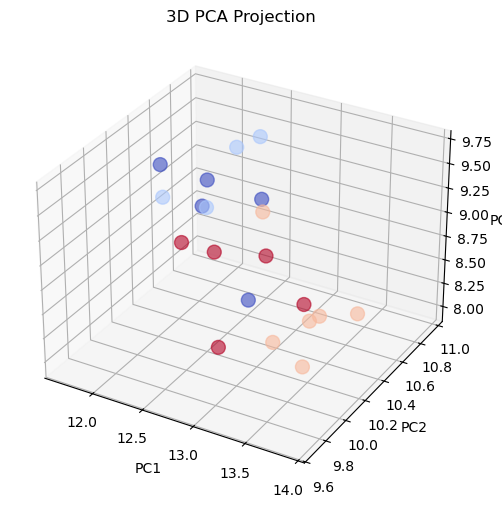

In [440]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pcaframe.r,
    pcaframe.s,
    pcaframe.x,
    c=pcaframe.lab_pca_score.astype(int),
    cmap="coolwarm",
    alpha=0.6,
    s=100
)

ax.set_title("3D PCA Projection")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()


In [441]:
from hdbscan import HDBSCAN

In [442]:
## HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) 
## Micro Clustering with outliers
hdbscan_model = HDBSCAN(min_cluster_size=3, metric="euclidean",cluster_selection_method="eom").fit(umap_embeddings)


In [443]:
clusters = hdbscan_model.labels_
print(len(set(clusters)))

3


In [444]:
## Cluster 0 ,Cluster 1 and -1 indicates Noise
clusters

array([ 1,  1,  0,  1,  1, -1,  0,  0, -1, -1,  0,  0,  0,  1, -1, -1,  0,
       -1, -1,  0])

In [445]:
for cluster in set(clusters):
    print(f"\nCluster {cluster}")
    print(reasons[clusters == cluster])



Cluster 0
['Limited range of services' 'Service dissatisfaction'
 'Lack of affordable download/upload speed'
 'Poor expertise of online support' 'Attitude of support person'
 'Network reliability' 'Attitude of service provider'
 'Lack of self-service on Website']

Cluster 1
['Competitor offered more data' 'Competitor made better offer'
 'Extra data charges' 'Competitor had better devices'
 'Competitor offered higher download speeds']

Cluster -1
["Don't know" 'Product dissatisfaction' 'Long distance charges' 'Moved'
 'Price too high' 'Poor expertise of phone support' 'Deceased']


# Cluster 0 (Service Experience Issues)
## Theme Service quality and Support problems
## Poor support, Bad service experience, Network issues 
## Website/self-service problems, Staff behavior
## Buisness Insight: This represents internal service dissatisfaction churn
## These customers left because “Your service is bad” as like 

# Cluster 1 (Price & Competitor Driven Churn)
## Theme Price sensitivity & competitor attraction
## Competitor offers, Better pricing elsewhere, Speed issues, Data plan issues
## Business Insight: This represents market-driven churn
## These customers left because “Someone else offered better value” as like

# Cluster -1 Outliers
## These are: Rare, Not theme-based, Hard to cluster
## HDBSCAN correctly marked them as noise.

In [446]:
umap_model_d = UMAP(n_components=2,random_state=42)
umap_embeddings_d = umap_model_d.fit_transform(embeddings)

C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\AKILAN M\anaconda3\envs\ds_env\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [447]:
print(umap_embeddings_d.shape)


(20, 2)


In [448]:
## Dataframe with 2 selected Dimentions implied as x any y

uframe = pd.DataFrame(umap_embeddings_d, columns=["x", "y"])

In [449]:
## Dataframe with reason and clusters

uframe["reasons"] = reasons
uframe["cluster"] = [str(c) for c in clusters]

In [450]:
uframe.head()

,x,y,reasons,cluster
0,16.742533,2.060713,Competitor offered more data,1
1,15.688500,2.394641,Competitor made better offer,1
2,17.042395,4.063723,Limited range of services,0
3,16.849604,1.560877,Extra data charges,1
4,16.192732,2.148539,Competitor had better devices,1


In [451]:
to_plot = uframe.loc[uframe.cluster != "-1", :]
outliers = uframe.loc[uframe.cluster == "-1", :]  

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_31860\3781619647.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


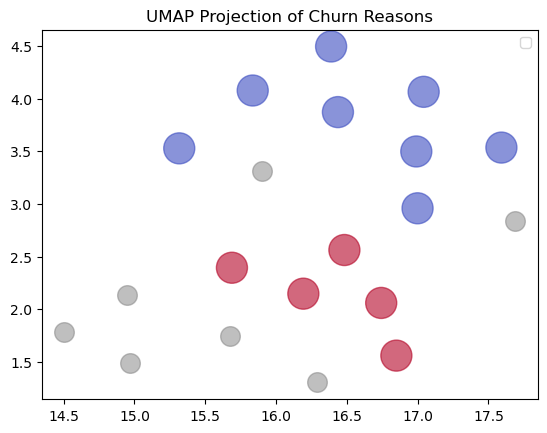

In [452]:
plt.scatter(outliers.x, outliers.y, alpha=0.5, s=200, c="grey")
plt.scatter(to_plot.x, to_plot.y, c= to_plot.cluster.astype(int), alpha=0.6, s=500, cmap="coolwarm" )
plt.legend()
plt.title("UMAP Projection of Churn Reasons")
plt.show()

##  HDBSCAN identified two broad churn themes, but PCA + KMeans provided finer segmentation into four actionable business categories: 
## service infrastructure, support behavior, competitive pricing, and miscellaneous churn drivers.
## PCA + KMeans is more interpretable
## HDBSCAN is more realistic for noisy large-scale text

In [453]:
def predict_reason_pca(text):
    emb = modelemb.encode([text])
    pca_emb = pca.transform(emb)
    cluster = kmeanemb.predict(pca_emb)[0]
    return cluster

In [454]:
## Predicting with random reason 
## Predicted into cluster 1 which is right as the reason depends on support failure

predict_reason_pca("Very bad customer support attitude")

np.int32(1)

In [455]:
## Dumping the Clustering PCA model as Pickle file

with open("clustering_model_pca_kmean.pkl", "wb") as f:
    pickle.dump({"pca": pca, "kmeans": kmeanemb}, f)

In [456]:
with open("clustering_model_umap_HDBSCAN.pkl", "wb") as f:
    pickle.dump({"UMAP": umap_embeddings , "HDBSCAN":hdbscan_model}, f)

# Topic System LLM

In [457]:
os.chdir(r"C:\Users\AKILAN M\Downloads")

In [458]:
cus_com = pd.read_csv("Comcast_telecom_complaints_data.csv")

In [459]:
cus_com.head()

,Ticket #,Customer Complaint,Date,Date_month_year,Time,Received Via,City,State,Zip code,Status,Filing on Behalf of Someone
0,250635,Comcast Cable Internet Speeds,22-04-2015,22-Apr-15,3:53:50 PM,Customer Care Call,Abingdon,Maryland,21009,Closed,No
1,223441,Payment disappear - service got disconnected,04-08-2015,04-Aug-15,10:22:56 AM,Internet,Acworth,Georgia,30102,Closed,No
2,242732,Speed and Service,18-04-2015,18-Apr-15,9:55:47 AM,Internet,Acworth,Georgia,30101,Closed,Yes
3,277946,Comcast Imposed a New Usage Cap of 300GB that punishes streaming.,05-07-2015,05-Jul-15,11:59:35 AM,Internet,Acworth,Georgia,30101,Open,Yes
4,307175,Comcast not working and no service to boot,26-05-2015,26-May-15,1:25:26 PM,Internet,Acworth,Georgia,30101,Solved,No


In [460]:
## Replacing the Industry name for the Systrm Learning
cus_com["Customer Complaint"] = cus_com["Customer Complaint"].str.replace(r"\b(comcast|comsat)\b","IBM",case=False,regex=True)



In [461]:
brands = words_to_remove = [
    "netflix","hbo","hbo go","hbogo","playstation","ps","ps3","ps4",
    "sony","xfinity","xfiniti","xfinitty","exfinity","comcast",
    "verizon","att","at&t","centurylink","earthlink","uverse",
    "amazon fire","ibm",
    "tv","cable","cable tv","internet","alarm",
    "home security","catv","locals","app","play","com","www","n/a",
    "and","to","for","with","company","service","customer"]


In [462]:
import re

pattern = r"\b(" + "|".join(brands) + r")\b"

cus_com["Customer Complaint"] = (cus_com["Customer Complaint"].str.lower().str.replace(pattern, "", regex=True).str.replace(r"\s+", " ", regex=True).str.strip())


In [463]:
len(cus_com["Customer Complaint"].unique().tolist())

1527

## collection of 1841 complains are stored in this data

In [464]:
## Cleaning the data Lowercasing

clean_docs = (
    cus_com["Customer Complaint"]
    .dropna()
    .astype(str)
    .str.strip())

clean_docs = clean_docs[clean_docs != ""]  # remove empty

cus_com = clean_docs.astype(str).tolist()  # convert to list LAST

In [465]:
len(cus_com)

2024

In [466]:
type(cus_com)

list

In [467]:
pd.isna(cus_com).sum()

np.int64(0)

# BERTopic Topic Model

In [468]:
from bertopic import BERTopic

In [469]:
from sklearn.feature_extraction.text import CountVectorizer

In [470]:
vectorizer_model = CountVectorizer(stop_words="english")

In [471]:
newemb = modelemb.encode(cus_com, show_progress_bar=True)

Batches: 100%|██████████| 64/64 [00:00<00:00, 73.66it/s]


In [472]:
umap_seg = UMAP(n_neighbors=5,n_components=5,min_dist=0.1,random_state=42)
umap_seg_emb = umap_seg.fit_transform(embeddings)

In [473]:
hdbscan_model_seg = HDBSCAN(min_cluster_size=5,min_samples=5, metric="euclidean",prediction_data=True,cluster_selection_method="eom").fit(umap_seg_emb)

In [474]:
newemb.shape

(2024, 384)

In [475]:
topic_model = BERTopic(embedding_model= modelemb, umap_model= umap_seg,hdbscan_model= hdbscan_model_seg ,verbose=True,vectorizer_model=vectorizer_model).fit(cus_com, newemb)

2026-03-07 19:43:27,193 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-07 19:43:31,949 - BERTopic - Dimensionality - Completed ✓
2026-03-07 19:43:31,949 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-07 19:43:32,016 - BERTopic - Cluster - Completed ✓
2026-03-07 19:43:32,022 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-03-07 19:43:32,117 - BERTopic - Representation - Completed ✓


In [476]:
type(topic_model)


bertopic._bertopic.BERTopic

In [477]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,211,-1_lied_plan_upgrade_technician,"[lied, plan, upgrade, technician, fee, resolution, help, termination, gouging, reliability]","[lied about $70 technician fee, agent lied about upgrade, being charged a technician fee]"
1,0,49,0_cap_data_comast_bullcrap,"[cap, data, comast, bullcrap, trials, lies, , , , ]","[data cap, data cap, data cap]"
2,1,46,1_billing_hookup_fradulent_pratice,"[billing, hookup, fradulent, pratice, marketing, devices, connection, , , ]","[-billing, billing, billing]"
3,2,33,2_contract_refusal_agreement_merger,"[contract, refusal, agreement, merger, recognize, signed, honoring, terms, promotion, business]","[business not honoring signed contract, refusal cancel under false contract claims, contract]"
4,3,33,3_caps_data_currently_commerce,"[caps, data, currently, commerce, grab, enforcing, discourage, nashville, selectively, methods]","[data caps, data caps, data caps]"
5,4,31,4_unfair_practices_billing_traffic,"[unfair, practices, billing, traffic, tiered, discriminatory, engaged, limitations, policies, regarding]","[unfair billing practices of, unfair billing practices, unfair billing practices]"
6,5,27,5_pricing_price_95_nh,"[pricing, price, 95, nh, francisco, concerns, competive, palmer, road, san]","[pricing, pricing, pricing]"
7,6,27,6_issues_correct_coast_ignoring,"[issues, correct, coast, ignoring, don, troubleshoot, reporting, west, various, making]","[issues, issues, issues]"
8,7,26,7_bundled_bundle_bundling_bundles,"[bundled, bundle, bundling, bundles, forced, package, model, denied, promissed, useless]","[bundled, bundled, bundled services]"
9,8,25,8_lies_deception_lied_wasted,"[lies, deception, lied, wasted, theft, cheating, errors, incompetence, crooks, fed]","[- errors, lies wasted time, lies deception, lies deception]"


In [478]:
topic_model.get_topic(0)

[('cap', np.float64(0.15380596913938424)),
 ('data', np.float64(0.08058882610067461)),
 ('comast', np.float64(0.03640756928141478)),
 ('bullcrap', np.float64(0.03640756928141478)),
 ('trials', np.float64(0.03640756928141478)),
 ('lies', np.float64(0.012738068471865302)),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05)]

In [479]:
topic_model.get_topic(1)

[('billing', np.float64(0.1122538785614565)),
 ('hookup', np.float64(0.07427144133408616)),
 ('fradulent', np.float64(0.06089044875446846)),
 ('pratice', np.float64(0.06089044875446846)),
 ('marketing', np.float64(0.04795790545596741)),
 ('devices', np.float64(0.04795790545596741)),
 ('connection', np.float64(0.014657750184189189)),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05)]

In [480]:
topic_model.find_topics("customer")

([54, 24, -1, 43, 114],
 [np.float32(0.5793117),
  np.float32(0.5109203),
  np.float32(0.50610465),
  np.float32(0.50119907),
  np.float32(0.49906752)])

In [481]:
topic_model.get_topic(39)

[('charges', np.float64(0.12077035791108616)),
 ('misc', np.float64(0.10036681261362995)),
 ('miss', np.float64(0.10036681261362995)),
 ('represented', np.float64(0.10036681261362995)),
 ('aware', np.float64(0.10036681261362995)),
 ('activation', np.float64(0.10036681261362995)),
 ('items', np.float64(0.10036681261362995)),
 ('kit', np.float64(0.10036681261362995)),
 ('etf', np.float64(0.10036681261362995)),
 ('unrelated', np.float64(0.10036681261362995))]

In [482]:

topic_model.find_topics("ibm internet")

([72, 18, 36, 10, 14],
 [np.float32(0.48180342),
  np.float32(0.4412226),
  np.float32(0.37913302),
  np.float32(0.3734161),
  np.float32(0.35555175)])

In [483]:
fig_topics = topic_model.visualize_documents(cus_com, reduced_embeddings= newemb, width=1200,hide_annotations=True)


In [484]:
import plotly.io as pio
print(pio.renderers)


Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype+notebook'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [485]:

pio.renderers.default = "notebook_connected"

In [486]:
fig_topics

In [487]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,211,-1_lied_plan_upgrade_technician,"[lied, plan, upgrade, technician, fee, resolution, help, termination, gouging, reliability]","[lied about $70 technician fee, agent lied about upgrade, being charged a technician fee]"
1,0,49,0_cap_data_comast_bullcrap,"[cap, data, comast, bullcrap, trials, lies, , , , ]","[data cap, data cap, data cap]"
2,1,46,1_billing_hookup_fradulent_pratice,"[billing, hookup, fradulent, pratice, marketing, devices, connection, , , ]","[-billing, billing, billing]"
3,2,33,2_contract_refusal_agreement_merger,"[contract, refusal, agreement, merger, recognize, signed, honoring, terms, promotion, business]","[business not honoring signed contract, refusal cancel under false contract claims, contract]"
4,3,33,3_caps_data_currently_commerce,"[caps, data, currently, commerce, grab, enforcing, discourage, nashville, selectively, methods]","[data caps, data caps, data caps]"
5,4,31,4_unfair_practices_billing_traffic,"[unfair, practices, billing, traffic, tiered, discriminatory, engaged, limitations, policies, regarding]","[unfair billing practices of, unfair billing practices, unfair billing practices]"
6,5,27,5_pricing_price_95_nh,"[pricing, price, 95, nh, francisco, concerns, competive, palmer, road, san]","[pricing, pricing, pricing]"
7,6,27,6_issues_correct_coast_ignoring,"[issues, correct, coast, ignoring, don, troubleshoot, reporting, west, various, making]","[issues, issues, issues]"
8,7,26,7_bundled_bundle_bundling_bundles,"[bundled, bundle, bundling, bundles, forced, package, model, denied, promissed, useless]","[bundled, bundled, bundled services]"
9,8,25,8_lies_deception_lied_wasted,"[lies, deception, lied, wasted, theft, cheating, errors, incompetence, crooks, fed]","[- errors, lies wasted time, lies deception, lies deception]"


In [488]:
topics, probs = topic_model.fit_transform(cus_com)

2026-03-07 19:43:34,113 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 64/64 [00:01<00:00, 59.02it/s]
2026-03-07 19:43:35,214 - BERTopic - Embedding - Completed ✓
2026-03-07 19:43:35,214 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-07 19:43:40,622 - BERTopic - Dimensionality - Completed ✓
2026-03-07 19:43:40,622 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-07 19:43:40,687 - BERTopic - Cluster - Completed ✓
2026-03-07 19:43:40,691 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-03-07 19:43:40,779 - BERTopic - Representation - Completed ✓


In [489]:
ibm_topic = pd.DataFrame({"text": cus_com,"topic": topics})

In [490]:
os.chdir(r"C:\Users\AKILAN M\Documents\GIT_Folder\IBM_CHURN")

In [491]:
## BERTopic saving the Topic model 

topic_model.save("my_topic_model_rl",serialization="safetensors")

In [492]:
topic_model.visualize_barchart()

In [493]:
topic_model.topic_representations_

{-1: [('lied', np.float64(0.014642452898079871)),
  ('plan', np.float64(0.01377550281683966)),
  ('upgrade', np.float64(0.013682711970318806)),
  ('technician', np.float64(0.013682711970318806)),
  ('fee', np.float64(0.013302178866164025)),
  ('resolution', np.float64(0.012537658073245191)),
  ('help', np.float64(0.01202860960990515)),
  ('termination', np.float64(0.011622721410904651)),
  ('gouging', np.float64(0.011394812383846447)),
  ('reliability', np.float64(0.011394812383846447))],
 0: [('cap', np.float64(0.15380596913938424)),
  ('data', np.float64(0.08058882610067461)),
  ('comast', np.float64(0.03640756928141478)),
  ('bullcrap', np.float64(0.03640756928141478)),
  ('trials', np.float64(0.03640756928141478)),
  ('lies', np.float64(0.012738068471865302)),
  ('', 1e-05),
  ('', 1e-05),
  ('', 1e-05),
  ('', 1e-05)],
 1: [('billing', np.float64(0.1122538785614565)),
  ('hookup', np.float64(0.07427144133408616)),
  ('fradulent', np.float64(0.06089044875446846)),
  ('pratice', np.

In [494]:
from copy import deepcopy

In [495]:
original_topics = deepcopy(topic_model.topic_representations_)

In [496]:
for i, j in list(original_topics.items())[:5]:
    print("Topic:", i)
    print("Words:", j)
    print("-" * 40)

Topic: -1
Words: [('lied', np.float64(0.014642452898079871)), ('plan', np.float64(0.01377550281683966)), ('upgrade', np.float64(0.013682711970318806)), ('technician', np.float64(0.013682711970318806)), ('fee', np.float64(0.013302178866164025)), ('resolution', np.float64(0.012537658073245191)), ('help', np.float64(0.01202860960990515)), ('termination', np.float64(0.011622721410904651)), ('gouging', np.float64(0.011394812383846447)), ('reliability', np.float64(0.011394812383846447))]
----------------------------------------
Topic: 0
Words: [('cap', np.float64(0.15380596913938424)), ('data', np.float64(0.08058882610067461)), ('comast', np.float64(0.03640756928141478)), ('bullcrap', np.float64(0.03640756928141478)), ('trials', np.float64(0.03640756928141478)), ('lies', np.float64(0.012738068471865302)), ('', 1e-05), ('', 1e-05), ('', 1e-05), ('', 1e-05)]
----------------------------------------
Topic: 1
Words: [('billing', np.float64(0.1122538785614565)), ('hookup', np.float64(0.0742714413

In [497]:
topic_model.reduce_topics(cus_com, nr_topics=12)

2026-03-07 19:43:41,370 - BERTopic - Topic reduction - Reducing number of topics
2026-03-07 19:43:41,405 - BERTopic - Topic reduction - Reduced number of topics from 130 to 12


In [498]:
ori_top = topic_model.topic_representations_

In [499]:
topic_model.visualize_barchart()

In [500]:
topic_model.save("topic_model_12_do_v2", serialization="safetensors")

In [501]:
topic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,211,-1_fee_speed_lied_plan,"[fee, speed, lied, plan, price, issue, paying, help, throttling, services]","[throttling speeds data caps, lied about $70 technician fee, being charged a technician fee]"
1,0,802,0_billing_practices_unfair_charges,"[billing, practices, unfair, charges, pricing, issues, price, false, deceptive, modem]","[billing, billing, billing]"
2,1,224,1_complaint_issues_problems_availability,"[complaint, issues, problems, availability, quality, failure, services, lack, communication, poor]","[complaint, complaint, complaint]"
3,2,219,2_data_cap_caps_usage,"[data, cap, caps, usage, 300gb, meter, overage, limit, atlanta, isp]","[data cap, data cap, data cap]"
4,3,209,3_speed_speeds_throttling_slow,"[speed, speeds, throttling, slow, advertised, throttled, paying, high, pay, mbps]","[speed throttling, throttling speed, speed throttling]"


In [502]:
topic_model.get_topics()

{-1: [('fee', np.float64(0.03892019002197523)),
  ('speed', np.float64(0.03678274356889378)),
  ('lied', np.float64(0.036102547953815185)),
  ('plan', np.float64(0.03246709959576188)),
  ('price', np.float64(0.03174172725853104)),
  ('issue', np.float64(0.031254632474340655)),
  ('paying', np.float64(0.030713872851059476)),
  ('help', np.float64(0.03027910901984621)),
  ('throttling', np.float64(0.028262456823965554)),
  ('services', np.float64(0.0280531579717284))],
 0: [('billing', np.float64(0.11354736332499689)),
  ('practices', np.float64(0.05987034373741007)),
  ('unfair', np.float64(0.05530593629698689)),
  ('charges', np.float64(0.04752265231645537)),
  ('pricing', np.float64(0.04105424347809777)),
  ('issues', np.float64(0.03805340523703341)),
  ('price', np.float64(0.031638565033031044)),
  ('false', np.float64(0.029828111092698055)),
  ('deceptive', np.float64(0.028689658443448885)),
  ('modem', np.float64(0.028540812838092844))],
 1: [('complaint', np.float64(0.216483150591

In [503]:
def topic_differences(model, original_topics, nr_topics=11):
    """Show the differences in topic representations between two models"""
    
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    
    for topic in range(nr_topics):
        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        
        df.loc[len(df)] = [topic, og_words, new_words]
    
    return df


In [504]:
 topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,cap | data | comast | bullcrap | trials,billing | practices | unfair | charges | pricing
1,1,billing | hookup | fradulent | pratice | marketing,complaint | issues | problems | availability | quality
2,2,contract | refusal | agreement | merger | recognize,data | cap | caps | usage | 300gb
3,3,caps | data | currently | commerce | grab,speed | speeds | throttling | slow | advertised
4,4,unfair | practices | billing | traffic | tiered,connection | intermittent | connectivity | outages | days
5,5,pricing | price | 95 | nh | francisco,october | 2014 | virtually | assistance | needed
6,6,issues | correct | coast | ignoring | don,terrible | poor | horrible | bad | awful
7,7,bundled | bundle | bundling | bundles | forced,phone | wifi | broadband | calls | provider
8,8,lies | deception | lied | wasted | theft,email | address | access | working | mail
9,9,fraudulent | card | collection | fraud | credit,blocking | bait | switch | streaming | blocks


In [505]:
## Key BERT 
from bertopic.representation import KeyBERTInspired

In [506]:
# Update our topic representations using KeyBERTInspired
representation_model_key = KeyBERTInspired()
topic_model.update_topics(cus_com, representation_model=representation_model_key)



In [507]:
topic_differences(topic_model, original_topics)


,Topic,Original,Updated
0,0,cap | data | comast | bullcrap | trials,billing | billed | payment | fees | account
1,1,billing | hookup | fradulent | pratice | marketing,complaint | complaints | complain | issues | problems
2,2,contract | refusal | agreement | merger | recognize,datacaps | cap | data | capping | caps
3,3,caps | data | currently | commerce | grab,throttling | throttle | throttles | throttled | speeds
4,4,unfair | practices | billing | traffic | tiered,connection | connectivity | connect | disconnection | disconnected
5,5,pricing | price | 95 | nh | francisco,no | only | | |
6,6,issues | correct | coast | ignoring | don,terrible | horrible | awful | bad | atrocious
7,7,bundled | bundle | bundling | bundles | forced,phone | telephone | calls | provider | dsl
8,8,lies | deception | lied | wasted | theft,email | emails | mail | address | unable
9,9,fraudulent | card | collection | fraud | credit,bait | switch | blocks | blocking | targeted


In [508]:
## Key BERT updated model title performance
topic_model.visualize_barchart()

In [509]:
from bertopic.representation import MaximalMarginalRelevance
# Update our topic representations to MaximalMarginalRelevance
representation_model_maxmar = MaximalMarginalRelevance(diversity=0.2)
topic_model.update_topics(cus_com, representation_model=representation_model_maxmar)

In [510]:
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,cap | data | comast | bullcrap | trials,billing | unfair | charges | pricing | modem
1,1,billing | hookup | fradulent | pratice | marketing,complaint | issues | problems | availability | failure
2,2,contract | refusal | agreement | merger | recognize,data | cap | 300gb | isp | overages
3,3,caps | data | currently | commerce | grab,speed | speeds | throttling | slow | throttled
4,4,unfair | practices | billing | traffic | tiered,connection | intermittent | connectivity | outages | outage
5,5,pricing | price | 95 | nh | francisco,no | go | on | only | 2014
6,6,issues | correct | coast | ignoring | don,terrible | poor | horrible | awful | experience
7,7,bundled | bundle | bundling | bundles | forced,phone | wifi | broadband | calls | provider
8,8,lies | deception | lied | wasted | theft,email | address | access | working | refuses
9,9,fraudulent | card | collection | fraud | credit,blocking | bait | switch | streaming | blocks


In [511]:
topic_model.visualize_barchart()

In [512]:
topic_model.save("topic_model_maxmin_up", serialization="safetensors")

In [513]:
from bertopic.representation import TextGeneration

In [514]:
from transformers import pipeline
from bertopic.representation import TextGeneration


In [515]:
import transformers
print(transformers.__version__)


4.41.2


# Topic Text Generator

In [516]:
prompt = """I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: '[KEYWORDS]'.
Based on the documents and keywords, what is this topic about?"""

In [517]:
# Update our topic representations using Flan-T5
generator = pipeline("text2text-generation", model="t5-small")


In [518]:
generatort2t = pipeline("text2text-generation",model="google/flan-t5-small",tokenizer="google/flan-t5-small")

In [519]:
generatort2t("Explain churn prediction", max_new_tokens=20)


[{'generated_text': 'churn prediction - wikipedia'}]

In [520]:
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,cap | data | comast | bullcrap | trials,billing | unfair | charges | pricing | modem
1,1,billing | hookup | fradulent | pratice | marketing,complaint | issues | problems | availability | failure
2,2,contract | refusal | agreement | merger | recognize,data | cap | 300gb | isp | overages
3,3,caps | data | currently | commerce | grab,speed | speeds | throttling | slow | throttled
4,4,unfair | practices | billing | traffic | tiered,connection | intermittent | connectivity | outages | outage
5,5,pricing | price | 95 | nh | francisco,no | go | on | only | 2014
6,6,issues | correct | coast | ignoring | don,terrible | poor | horrible | awful | experience
7,7,bundled | bundle | bundling | bundles | forced,phone | wifi | broadband | calls | provider
8,8,lies | deception | lied | wasted | theft,email | address | access | working | refuses
9,9,fraudulent | card | collection | fraud | credit,blocking | bait | switch | streaming | blocks


In [521]:
topic_model.get_topic_info()[:15]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,211,-1_fee_lied_paying_data,"[fee, lied, paying, data, throttling, services, speeds, upgrade, fees, charged]","[throttling speeds data caps, lied about $70 technician fee, being charged a technician fee]"
1,0,802,0_billing_unfair_charges_pricing,"[billing, unfair, charges, pricing, modem, fraudulent, contract, monopoly, refund, fees]","[billing, billing, billing]"
2,1,224,1_complaint_issues_problems_availability,"[complaint, issues, problems, availability, failure, quality, services, communication, support, deliver]","[complaint, complaint, complaint]"
3,2,219,2_data_cap_300gb_isp,"[data, cap, 300gb, isp, overages, bandwidth, limits, ga, broadband, monthly]","[data cap, data cap, data cap]"
4,3,209,3_speed_speeds_throttling_slow,"[speed, speeds, throttling, slow, throttled, mbps, throttles, throttle, prices, mb]","[speed throttling, throttling speed, speed throttling]"
5,4,114,4_connection_intermittent_connectivity_outages,"[connection, intermittent, connectivity, outages, outage, disconnected, disconnection, slowness, signal, issues]","[connection speed issues, connection speed, intermittent connection]"
6,5,58,5_no_go_on_only,"[no, go, on, only, 2014, october, about, assistance, month, ]","[needed!, no , no assistance, - virtually no since october 2014]"
7,6,51,6_terrible_poor_horrible_awful,"[terrible, poor, horrible, awful, experience, atrocious, ripped, sight, treatment, rude]","[terrible, terrible #2, is a terrible]"
8,7,45,7_phone_wifi_broadband_calls,"[phone, wifi, broadband, calls, provider, florida, unresponsive, jacksonville, comcastcomcas, dsl]","[my bill //phone, /phone, phone]"
9,8,44,8_email_address_access_working,"[email, address, access, working, refuses, emails, residential, transfer, account, unable]","[no email from, un able access my email address after relocae a new address, cannot access my email or at all]"


In [522]:
topic_model.visualize_barchart()

In [523]:
from bertopic.representation import OpenAI

In [524]:
import transformers

In [525]:
import psutil
print(round(psutil.virtual_memory().total / (1024**3), 2), "GB RAM")


15.27 GB RAM


In [526]:
import torch

In [527]:
import transformers
import sentence_transformers
import bertopic

print(transformers.__version__)
print(sentence_transformers.__version__)
print(bertopic.__version__)

4.41.2
5.2.3
0.16.0


In [528]:
os.getcwd()

'C:\\Users\\AKILAN M\\Documents\\GIT_Folder\\IBM_CHURN'

In [529]:
ds = topic_model.get_topic_info()


In [530]:
ds.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,211,-1_fee_lied_paying_data,"[fee, lied, paying, data, throttling, services, speeds, upgrade, fees, charged]","[throttling speeds data caps, lied about $70 technician fee, being charged a technician fee]"
1,0,802,0_billing_unfair_charges_pricing,"[billing, unfair, charges, pricing, modem, fraudulent, contract, monopoly, refund, fees]","[billing, billing, billing]"
2,1,224,1_complaint_issues_problems_availability,"[complaint, issues, problems, availability, failure, quality, services, communication, support, deliver]","[complaint, complaint, complaint]"
3,2,219,2_data_cap_300gb_isp,"[data, cap, 300gb, isp, overages, bandwidth, limits, ga, broadband, monthly]","[data cap, data cap, data cap]"
4,3,209,3_speed_speeds_throttling_slow,"[speed, speeds, throttling, slow, throttled, mbps, throttles, throttle, prices, mb]","[speed throttling, throttling speed, speed throttling]"


In [531]:
len(cus_com)

2024

In [532]:
representation_model_txtgen = TextGeneration(
    generatort2t,
    prompt=prompt,
    doc_length=50,tokenizer="whitespace")

In [533]:
topic_model.update_topics(cus_com,representation_model=representation_model_txtgen)
# Show topic differences

100%|██████████| 12/12 [00:01<00:00,  8.35it/s]


In [534]:
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,cap | data | comast | bullcrap | trials,billing | | | |
1,1,billing | hookup | fradulent | pratice | marketing,complaint | | | |
2,2,contract | refusal | agreement | merger | recognize,data cap | | | |
3,3,caps | data | currently | commerce | grab,bandwidth | | | |
4,4,unfair | practices | billing | traffic | tiered,connection issues | | | |
5,5,pricing | price | 95 | nh | francisco,october 2014 | | | |
6,6,issues | correct | coast | ignoring | don,a horrible experience | | | |
7,7,bundled | bundle | bundling | bundles | forced,phone | | | |
8,8,lies | deception | lied | wasted | theft,email | | | |
9,9,fraudulent | card | collection | fraud | credit,block | | | |


In [535]:
new_complaint = ["Internet speed is slow and disconnects often"]

In [536]:
predicted_topic, probability = topic_model.transform(new_complaint)

print("Predicted Topic:", predicted_topic[0])
print("Probability:", probability[0])

Batches: 100%|██████████| 1/1 [00:00<00:00, 75.56it/s]
2026-03-07 19:43:48,723 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-07 19:43:52,770 - BERTopic - Dimensionality - Completed ✓
2026-03-07 19:43:52,770 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-07 19:43:52,780 - BERTopic - Cluster - Completed ✓


Predicted Topic: 4
Probability: 0.7392253472111472


In [537]:
topic_id = predicted_topic[0] 
topic_words = topic_model.get_topic(topic_id)

In [538]:
topic_info = topic_model.get_topic_info()

In [539]:
topic_info["Clean_Name"] = topic_info["Name"].str.replace(r"^\d+_", "", regex=True)

In [540]:
topic_info["Clean_Name"] = topic_info["Clean_Name"].str.replace(r"^-?\d+_", "", regex=True)

In [541]:
topic_info["Clean_Name"]

0                      bill___
1                   billing___
2                 complaint___
3                  data cap___
4                 bandwidth___
5         connection issues___
6              october 2014___
7     a horrible experience___
8                     phone___
9                     email___
10                    block___
11             installation___
Name: Clean_Name, dtype: object

In [542]:
label_mapping = dict(zip(topic_info["Topic"], topic_info["Clean_Name"]))

In [543]:
import json

In [544]:
with open("topic_labels.json", "w") as f:
    json.dump(label_mapping, f)

In [545]:
topic_info[["Topic","Name"]]

,Topic,Name
0,-1,-1_bill___
1,0,0_billing___
2,1,1_complaint___
3,2,2_data cap___
4,3,3_bandwidth___
5,4,4_connection issues___
6,5,5_october 2014___
7,6,6_a horrible experience___
8,7,7_phone___
9,8,8_email___


In [546]:
keywords = ", ".join([word for word, _ in topic_words[:6]])

In [547]:
output = generatort2t(prompt,max_new_tokens=8, do_sample=False)

print(output)

[{'generated_text': 'Business'}]


In [548]:
label = output[0]["generated_text"].split("Label:")[-1].strip()

In [549]:
def generate_label(prompt):
    output = generatort2t(prompt, max_new_tokens=10, do_sample=False)
    return output[0]["generated_text"]



## Topic Labeling Model pkl file

In [550]:
topic_model.save("topic_label_model_final",serialization="safetensors")